In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp2d
from scipy.interpolate import griddata
import glob 

In [2]:
filenames = {}
for file in glob.glob("../RA/*.csv"): 
    center = float(file.split("r_")[1].split("_m")[0])
    filenames[center] = file

weights = {} 
poles = {}

for center in filenames: 
    wp = np.genfromtxt(filenames[center], delimiter=",")
    weights[center] = wp[0,:]
    poles[center] = wp[1,:]
m = weights[center].shape[0]

# Scenario 0: Marmousi 

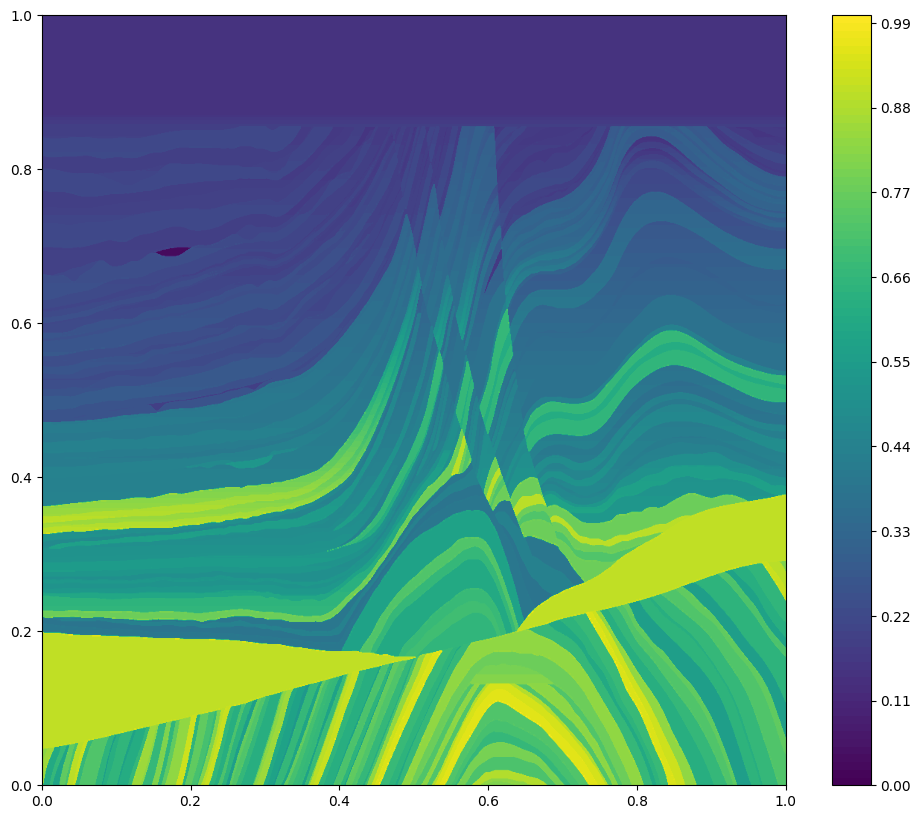

In [3]:
data_reduced = np.genfromtxt("marmousi_reduced.csv", delimiter=",")
plt.figure(figsize=(12,10))
plt.contourf(data_reduced,  extent = [0,1,1,0],levels=100)
plt.colorbar()

## Creation of weights and poles for a center from 1.0 to 2.0 

In [5]:
rata = np.round(2 * data_reduced + 0.5, 2)
print(rata)

weights01 = np.zeros((rata.shape[0], rata.shape[1], m))
weights12 = np.zeros((rata.shape[0], rata.shape[1], m))
weights23 = np.zeros((rata.shape[0], rata.shape[1], m))
poles01 = np.zeros((rata.shape[0], rata.shape[1], m))
poles12 = np.zeros((rata.shape[0], rata.shape[1], m))
poles23 = np.zeros((rata.shape[0], rata.shape[1], m))

for idx, row in enumerate(rata): 
    for idy, center in enumerate(row): 
        if (center < 1.1):
            weights01[idx, idy] = weights[np.round(center,2)]
            poles01[idx, idy] = -poles[np.round(center,2)]
        if (0.9 < center and center < 2.1): 
            weights12[idx, idy] = weights[np.round(center-1,2)]
            poles12[idx, idy] = -poles[np.round(center-1,2)]
        if (1.9 < center): 
            weights23[idx, idy] = weights[np.round(center-2,2)]
            poles23[idx, idy] = -poles[np.round(center-2,2)]

[[0.79 0.79 0.79 ... 0.79 0.79 0.79]
 [0.79 0.79 0.79 ... 0.79 0.79 0.79]
 [0.79 0.79 0.79 ... 0.79 0.79 0.79]
 ...
 [2.21 2.21 1.71 ... 1.96 1.96 1.96]
 [2.21 2.21 1.71 ... 1.96 1.96 1.96]
 [2.21 2.21 1.7  ... 1.96 1.96 1.96]]


In [9]:
for i in range(m): 
    np.savetxt("weights_n_poles_sc0/weights01_" + str(i) + ".csv", weights01[::-1,:,i], delimiter=",")    
    np.savetxt("weights_n_poles_sc0/weights12_" + str(i) + ".csv", weights12[::-1,:,i], delimiter=",")    
    np.savetxt("weights_n_poles_sc0/weights23_" + str(i) + ".csv", weights23[::-1,:,i], delimiter=",")    
    np.savetxt("weights_n_poles_sc0/poles01_" + str(i) + ".csv", poles01[::-1,:,i], delimiter=",")    
    np.savetxt("weights_n_poles_sc0/poles12_" + str(i) + ".csv", poles12[::-1,:,i], delimiter=",")    
    np.savetxt("weights_n_poles_sc0/poles23_" + str(i) + ".csv", poles23[::-1,:,i], delimiter=",")     

np.savetxt("alpha_sc0.csv", rata[::-1,:], delimiter=",")

# Scenario 1: Random field 

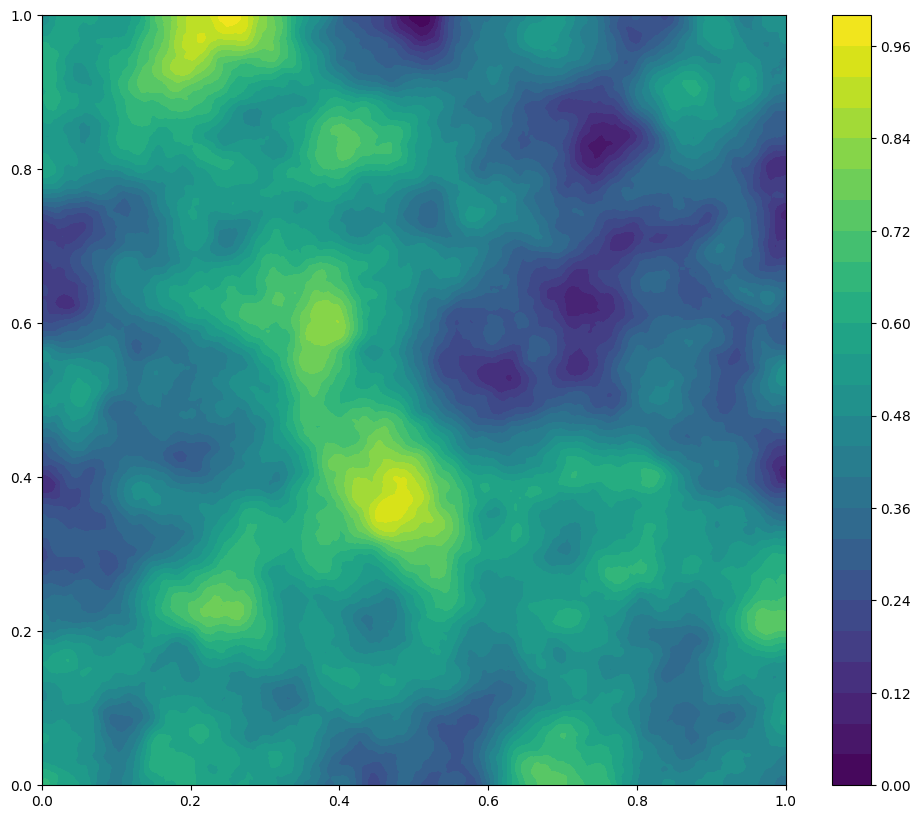

In [6]:
rf_values = np.loadtxt('randomfields/coarserf.000000')
rf_vertex = np.loadtxt('randomfields/coarsemesh.000000')
rf_data = np.zeros((rf_values.shape[0], 3))
rf_data[:,0:2] = rf_vertex
rf_data[:,2] = rf_values

x = np.linspace(0, 1, 1000)
y = np.linspace(0, 1, 1000)
X, Y = np.meshgrid(x,y)
Z = griddata((rf_data[:,0], rf_data[:,1]), rf_data[:,2], (X, Y), method='cubic')

data_reduced = Z 
data_reduced -= data_reduced.min()
data_reduced /= data_reduced.max()

plt.figure(figsize=(12,10))
plt.contourf(X,Y,data_reduced,levels=30)
plt.colorbar()

In [7]:
rata = np.round(2 * data_reduced + 0.5, 2)
print(rata)

weights01 = np.zeros((rata.shape[0], rata.shape[1], m))
weights12 = np.zeros((rata.shape[0], rata.shape[1], m))
weights23 = np.zeros((rata.shape[0], rata.shape[1], m))
poles01 = np.zeros((rata.shape[0], rata.shape[1], m))
poles12 = np.zeros((rata.shape[0], rata.shape[1], m))
poles23 = np.zeros((rata.shape[0], rata.shape[1], m))

for idx, row in enumerate(rata): 
    for idy, center in enumerate(row): 
        if (center < 1.1):
            weights01[idx, idy] = weights[np.round(center,2)]
            poles01[idx, idy] = -poles[np.round(center,2)]
        if (0.9 < center and center < 2.1): 
            weights12[idx, idy] = weights[np.round(center-1,2)]
            poles12[idx, idy] = -poles[np.round(center-1,2)]
        if (1.9 < center): 
            weights23[idx, idy] = weights[np.round(center-2,2)]
            poles23[idx, idy] = -poles[np.round(center-2,2)]

[[1.81 1.81 1.81 ... 1.27 1.27 1.27]
 [1.8  1.8  1.8  ... 1.27 1.27 1.27]
 [1.8  1.8  1.8  ... 1.27 1.27 1.27]
 ...
 [1.45 1.45 1.45 ... 1.54 1.54 1.54]
 [1.44 1.44 1.45 ... 1.54 1.54 1.54]
 [1.45 1.44 1.44 ... 1.54 1.54 1.54]]


In [12]:
for i in range(m): 
    np.savetxt("weights_n_poles_sc1/weights01_" + str(i) + ".csv", weights01[:,:,i], delimiter=",")    
    np.savetxt("weights_n_poles_sc1/weights12_" + str(i) + ".csv", weights12[:,:,i], delimiter=",")    
    np.savetxt("weights_n_poles_sc1/weights23_" + str(i) + ".csv", weights23[:,:,i], delimiter=",")    
    np.savetxt("weights_n_poles_sc1/poles01_" + str(i) + ".csv", poles01[:,:,i], delimiter=",")    
    np.savetxt("weights_n_poles_sc1/poles12_" + str(i) + ".csv", poles12[:,:,i], delimiter=",")    
    np.savetxt("weights_n_poles_sc1/poles23_" + str(i) + ".csv", poles23[:,:,i], delimiter=",")     

np.savetxt("alpha_sc1.csv", rata, delimiter=",")

# Scenario 2: Toy example 

In [8]:
def f(x): 
    middle = (x>1/4) * (x<3/4)
    right = x > 3/4
    return middle * (1 - np.cos((x-1/4) * 2 * np.pi)) * 0.5 + 1 * right

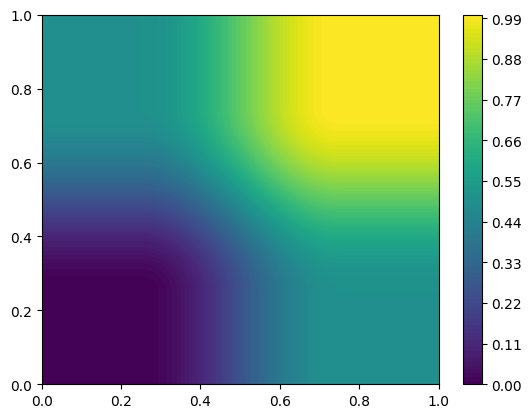

In [9]:
x = np.linspace(0, 1, 1000)
y = np.linspace(0, 1, 1000)
X, Y = np.meshgrid(x,y)

def f(x): 
    middle = (x>1/4) * (x<3/4)
    right = x > 3/4
    return middle * (1 - np.cos((x-1/4) * 2 * np.pi)) * 0.5 + 1 * right

Z = 0.5 * (f(X) + f(Y))

plt.contourf(X,Y,Z,levels=100)
plt.colorbar()

data_reduced = Z 
data_reduced -= data_reduced.min()
data_reduced /= data_reduced.max()

In [10]:
rata = np.round(2 * data_reduced + 0.5, 2)
print(rata)

weights01 = np.zeros((rata.shape[0], rata.shape[1], m))
weights12 = np.zeros((rata.shape[0], rata.shape[1], m))
weights23 = np.zeros((rata.shape[0], rata.shape[1], m))
poles01 = np.zeros((rata.shape[0], rata.shape[1], m))
poles12 = np.zeros((rata.shape[0], rata.shape[1], m))
poles23 = np.zeros((rata.shape[0], rata.shape[1], m))

for idx, row in enumerate(rata): 
    for idy, center in enumerate(row): 
        if (center < 1.1):
            weights01[idx, idy] = weights[np.round(center,2)]
            poles01[idx, idy] = -poles[np.round(center,2)]
        if (0.9 < center and center < 2.1): 
            weights12[idx, idy] = weights[np.round(center-1,2)]
            poles12[idx, idy] = -poles[np.round(center-1,2)]
        if (1.9 < center): 
            weights23[idx, idy] = weights[np.round(center-2,2)]
            poles23[idx, idy] = -poles[np.round(center-2,2)]

[[0.5 0.5 0.5 ... 1.5 1.5 1.5]
 [0.5 0.5 0.5 ... 1.5 1.5 1.5]
 [0.5 0.5 0.5 ... 1.5 1.5 1.5]
 ...
 [1.5 1.5 1.5 ... 2.5 2.5 2.5]
 [1.5 1.5 1.5 ... 2.5 2.5 2.5]
 [1.5 1.5 1.5 ... 2.5 2.5 2.5]]


In [19]:
for i in range(m): 
    np.savetxt("weights_n_poles_sc2/weights01_" + str(i) + ".csv", weights01[:,:,i], delimiter=",")    
    np.savetxt("weights_n_poles_sc2/weights12_" + str(i) + ".csv", weights12[:,:,i], delimiter=",")    
    np.savetxt("weights_n_poles_sc2/weights23_" + str(i) + ".csv", weights23[:,:,i], delimiter=",")    
    np.savetxt("weights_n_poles_sc2/poles01_" + str(i) + ".csv", poles01[:,:,i], delimiter=",")    
    np.savetxt("weights_n_poles_sc2/poles12_" + str(i) + ".csv", poles12[:,:,i], delimiter=",")    
    np.savetxt("weights_n_poles_sc2/poles23_" + str(i) + ".csv", poles23[:,:,i], delimiter=",")     

np.savetxt("alpha_sc2.csv", rata, delimiter=",")